# 02b -- Preprocessing Helpers

This notebook is the preprocessing-only replica of Mohsen's helper workflow.

It preserves the preprocessing outputs that lead into feature extraction:

- minimum-duration filtering for `ACC_Z`
- retained/removed record summaries
- common-event discovery for one representative deck example
- multichannel waveform-matrix loading
- zero-phase `0.5-20 Hz` band-pass preparation

FDD, peak picking, mode-shape tables, mode-shape plots, and singular-value spectra remain in `03_feature_extraction.ipynb`.


In [1]:
from pathlib import Path

from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import pandas as pd

from aquinas_toolkit import AquinasReader
from aquinas_toolkit.preprocessing import (
    bandpass_filter_waveform_matrix,
    find_common_sensor_events,
    load_common_event_waveform_matrix,
    summarize_min_duration_filter,
)

MIN_DURATION_SECONDS = 10.0
DATASET_ROOT = Path("../AQUINAS_DATASET")
SAMPLE_RATE_HZ = 100.0
LOW_HZ = 0.5
HIGH_HZ = 20.0
EXAMPLE_DECK = "OLD"


In [2]:
set_summaries = []

for set_dir in sorted(DATASET_ROOT.glob("AQUINAS_SET*")):
    reader = AquinasReader(set_dir)
    sensor_summary = summarize_min_duration_filter(
        reader,
        min_duration_seconds=MIN_DURATION_SECONDS,
        quantity="ACC",
        axis="Z",
    )

    set_summaries.append(
        {
            "Dataset": reader.set_name,
            "Sensors": len(sensor_summary),
            "Total records": int(sensor_summary["record_count"].sum()),
            "Kept": int(sensor_summary["kept_count"].sum()),
            "Removed": int(sensor_summary["removed_count"].sum()),
            "Removed %": sensor_summary["removed_count"].sum() / sensor_summary["record_count"].sum(),
        }
    )

    display(
        sensor_summary[
            [
                "sensor_name",
                "deck",
                "span",
                "side",
                "location",
                "record_count",
                "kept_count",
                "removed_count",
                "kept_fraction",
            ]
        ]
        .rename(
            columns={
                "sensor_name": "Sensor",
                "deck": "Deck",
                "span": "Span",
                "side": "Side",
                "location": "Location",
                "record_count": "Total records",
                "kept_count": "Kept",
                "removed_count": "Removed",
                "kept_fraction": "Kept %",
            }
        )
        .style.hide(axis="index")
        .format({"Total records": "{:,.0f}", "Kept": "{:,.0f}", "Removed": "{:,.0f}", "Kept %": "{:.1%}"})
        .set_caption(
            f"{reader.set_name} — ACC_Z records kept after minimum duration filter ({MIN_DURATION_SECONDS:.0f} s)"
        )
    )

display(
    pd.DataFrame(set_summaries)
    .style.hide(axis="index")
    .format({"Sensors": "{:,.0f}", "Total records": "{:,.0f}", "Kept": "{:,.0f}", "Removed": "{:,.0f}", "Removed %": "{:.1%}"})
    .set_caption(
        f"ACC_Z minimum duration filter summary across all datasets ({MIN_DURATION_SECONDS:.0f} s threshold)"
    )
)


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"3,632","3,630",2,99.9%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"3,632","3,630",2,99.9%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"3,633","3,630",3,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"3,633","3,630",3,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"3,632","3,630",2,99.9%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"3,632","3,630",2,99.9%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"3,633","3,630",3,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"3,633","3,630",3,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,948","3,946",2,99.9%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,948","3,946",2,99.9%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"1,678","1,672",6,99.6%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"1,678","1,672",6,99.6%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"1,678","1,672",6,99.6%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"1,678","1,672",6,99.6%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"1,678","1,672",6,99.6%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"1,678","1,672",6,99.6%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"1,678","1,672",6,99.6%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"1,678","1,672",6,99.6%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"2,105","2,104",1,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"2,105","2,104",1,100.0%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"3,493","3,492",1,100.0%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"3,493","3,492",1,100.0%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"3,494","3,492",2,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"3,494","3,492",2,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"3,493","3,492",1,100.0%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"3,493","3,492",1,100.0%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"3,494","3,492",2,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"3,494","3,492",2,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,005","3,005",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,006","3,005",1,100.0%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,867,866,1,99.9%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,867,866,1,99.9%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,867,866,1,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,867,866,1,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,867,866,1,99.9%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,867,866,1,99.9%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,867,866,1,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,867,866,1,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"1,479","1,479",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"1,479","1,479",0,100.0%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"2,577","2,577",0,100.0%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"2,577","2,577",0,100.0%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"2,577","2,577",0,100.0%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"2,577","2,577",0,100.0%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"2,577","2,577",0,100.0%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"2,577","2,577",0,100.0%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"2,577","2,577",0,100.0%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"2,577","2,577",0,100.0%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,350","3,350",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,350","3,350",0,100.0%


Dataset,Sensors,Total records,Kept,Removed,Removed %
AQUINAS_SET1_2022_07,16,"60,639","60,603",36,0.1%
AQUINAS_SET2_2023_04,16,"30,264","30,208",56,0.2%
AQUINAS_SET3_2023_08,16,"51,990","51,972",18,0.0%
AQUINAS_SET4_2024_01,16,"18,768","18,760",8,0.0%
AQUINAS_SET5_2024_06,16,"47,416","47,416",0,0.0%


## Zero-phase band-pass preparation before FDD

This section stops exactly at the handoff point where `03_feature_extraction.ipynb` takes over.


In [3]:
example_set_dir = sorted(DATASET_ROOT.glob("AQUINAS_SET*"))[0]
reader = AquinasReader(example_set_dir)
common_events = find_common_sensor_events(
    reader,
    min_duration_seconds=MIN_DURATION_SECONDS,
    quantity="ACC",
    axis="Z",
    deck=EXAMPLE_DECK,
)

display(Markdown(f"### {reader.set_name} | {EXAMPLE_DECK}"))
display(
    common_events[["Start_Time", "End_Time", "sensor_count", "channel_count"]]
    .rename(
        columns={
            "Start_Time": "Start time",
            "End_Time": "End time",
            "sensor_count": "Sensor count",
            "channel_count": "Channel count",
        }
    )
    .head(10)
    .style.hide(axis="index")
    .format({"Sensor count": "{:,.0f}", "Channel count": "{:,.0f}"})
    .set_caption(f"{reader.set_name} | {EXAMPLE_DECK} — first common ACC_Z events before filtering")
)


### AQUINAS_SET1_2022_07 | OLD

Start time,End time,Sensor count,Channel count
2022-07-01 01:47:16,2022-07-01 01:47:31,8,8
2022-07-01 02:09:21,2022-07-01 02:09:34,8,8
2022-07-01 02:43:04,2022-07-01 02:43:19,8,8
2022-07-01 02:44:53,2022-07-01 02:45:07,8,8
2022-07-01 02:57:59,2022-07-01 02:58:13,8,8
2022-07-01 03:02:01,2022-07-01 03:02:16,8,8
2022-07-01 03:33:41,2022-07-01 03:33:55,8,8
2022-07-01 03:46:08,2022-07-01 03:46:20,8,8
2022-07-01 03:50:29,2022-07-01 03:50:42,8,8
2022-07-01 03:53:42,2022-07-01 03:53:54,8,8


In [4]:
event = common_events.iloc[0]

waveform_matrix = load_common_event_waveform_matrix(
    reader,
    start_time=event["Start_Time"],
    end_time=event["End_Time"],
    sensor_names=event["sensor_names"],
)
filtered_matrix = bandpass_filter_waveform_matrix(
    waveform_matrix,
    sampling_rate_hz=SAMPLE_RATE_HZ,
    low_hz=LOW_HZ,
    high_hz=HIGH_HZ,
)

display(
    waveform_matrix.head()
    .style.hide(axis="index")
    .set_caption(f"{reader.set_name} | {EXAMPLE_DECK} — raw waveform matrix preview")
)
display(
    filtered_matrix.head()
    .style.hide(axis="index")
    .set_caption(f"{reader.set_name} | {EXAMPLE_DECK} — zero-phase band-pass filtered waveform matrix preview")
)


timestamp,OLD_S1_DO_INT_ACC_Z,OLD_S1_DO_MID_ACC_Z,OLD_S1_UP_INT_ACC_Z,OLD_S1_UP_MID_ACC_Z,OLD_S2_DO_INT_ACC_Z,OLD_S2_DO_MID_ACC_Z,OLD_S2_UP_INT_ACC_Z,OLD_S2_UP_MID_ACC_Z
2022-07-01 01:47:16.446,1.005900,1.029900,1.030600,1.029900,1.019000,1.023500,1.015300,1.037500
2022-07-01 01:47:16.456,1.006000,1.030100,1.030200,1.029100,1.019600,1.022900,1.015500,1.037300
2022-07-01 01:47:16.466,1.005700,1.030100,1.030200,1.029500,1.017800,1.022200,1.016100,1.037900
2022-07-01 01:47:16.476,1.004100,1.029400,1.030200,1.029300,1.015900,1.023700,1.017100,1.038700
2022-07-01 01:47:16.486,1.008100,1.028800,1.030800,1.029700,1.017600,1.024700,1.017300,1.039400


timestamp,OLD_S1_DO_INT_ACC_Z,OLD_S1_DO_MID_ACC_Z,OLD_S1_UP_INT_ACC_Z,OLD_S1_UP_MID_ACC_Z,OLD_S2_DO_INT_ACC_Z,OLD_S2_DO_MID_ACC_Z,OLD_S2_UP_INT_ACC_Z,OLD_S2_UP_MID_ACC_Z
2022-07-01 01:47:16.446,0.000317,0.000004,0.000004,-0.000056,-0.000047,0.000040,0.000073,0.000005
2022-07-01 01:47:16.456,-0.000314,0.000184,-0.000312,-0.000503,-0.000490,-0.000589,0.000391,0.000019
2022-07-01 01:47:16.466,-0.000333,0.000013,-0.000422,-0.000663,-0.001139,-0.000701,0.000947,0.000371
2022-07-01 01:47:16.476,0.000396,-0.000442,-0.000291,-0.000531,-0.001808,-0.000265,0.001607,0.001028
2022-07-01 01:47:16.486,0.001272,-0.000779,-0.000059,-0.000339,-0.002093,0.000378,0.001956,0.001640


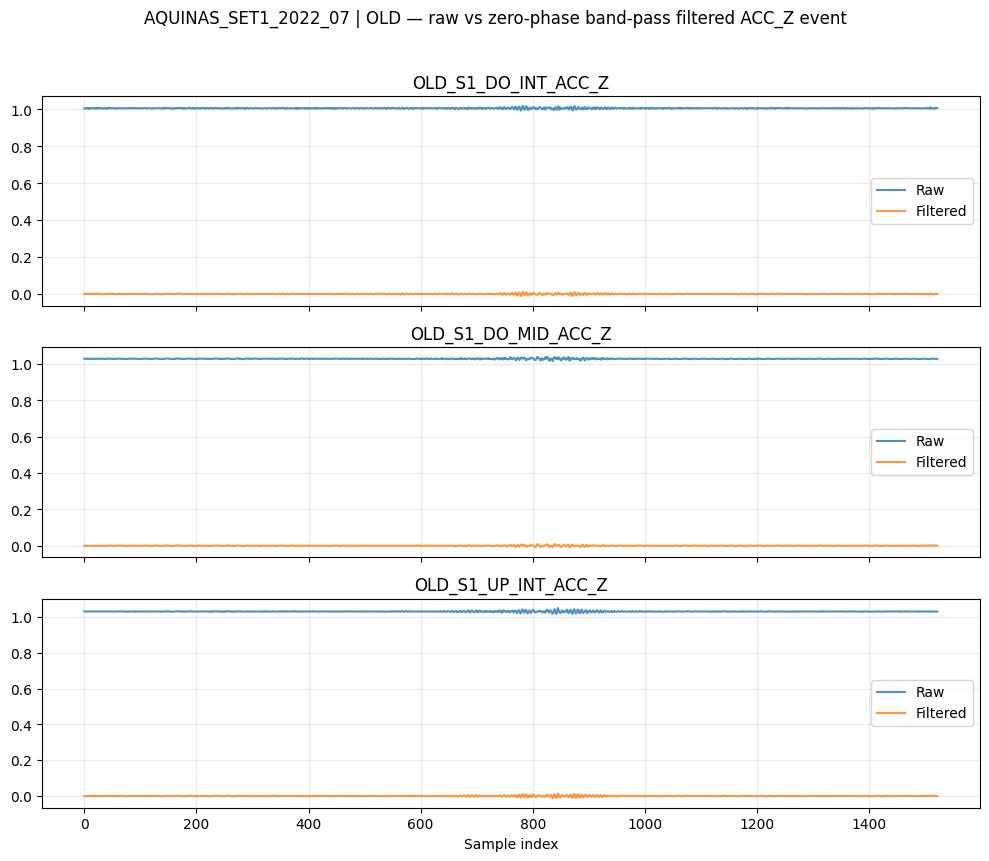

In [5]:
channels = [column for column in waveform_matrix.columns if column != "timestamp"]
plot_channels = channels[: min(3, len(channels))]

fig, axes = plt.subplots(len(plot_channels), 1, figsize=(10, 2.8 * len(plot_channels)), sharex=True)
if len(plot_channels) == 1:
    axes = [axes]

for axis, channel in zip(axes, plot_channels, strict=True):
    axis.plot(waveform_matrix.index, waveform_matrix[channel], label="Raw", alpha=0.8)
    axis.plot(filtered_matrix.index, filtered_matrix[channel], label="Filtered", alpha=0.8)
    axis.set_title(channel)
    axis.grid(alpha=0.25)
    axis.legend()

axes[-1].set_xlabel("Sample index")
fig.suptitle(f"{reader.set_name} | {EXAMPLE_DECK} — raw vs zero-phase band-pass filtered ACC_Z event", y=1.02)
fig.tight_layout()
plt.show()
